# Clusters con trayectoria pivote
El presente notebook intenta demostrar otra de las útilidades que se le pueden dar al paquete `stmeasures`.

> Este notebook se realizó con las versiones:
> - [`dev51589907`](https://test.pypi.org/project/stmeasures/0.0.0a0.dev51589907/)
> - [`dev50566726`](https://test.pypi.org/project/stmeasures/0.0.0a0.dev50566726/)

In [1]:
import stmeasures
import shapely
import utils
import geojsonio

Se pretenderá de un dataset (archivo en formato GeoJSON) que contiene trayectorias clusterizar tomando como pivote una trayectoria y ver como se comportan con los algoritmos implementados.

In [2]:
datasetec = stmeasures.read_file('../assets/ECATEPEC.json')

Se usará como pivoté la siguiente trayectoria

In [3]:
pivot_trajectory = datasetec[99]
_ = geojsonio.display(stmeasures.geojsonio_contents(trajectory=pivot_trajectory))

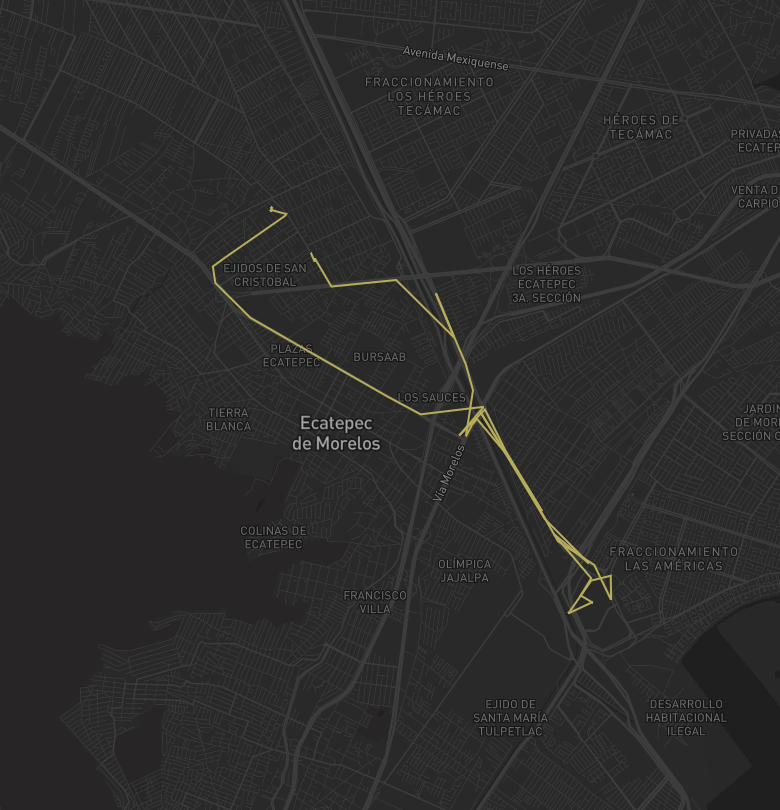

## Algoritmos finales seleccionados

Se empiezan haciendo estas pruebas de clusterización con los siguientes algoritmos (que fueron los más útiles que encontramos para nuestros datos):

1. Euclideano
2. Hausdorff
3. Frechet
4. AMSS

### Algoritmo euclideano

Para este algoritmo se observarán resultados con nuestro paquete y con el paquete `shapely` de igual modo.

#### Euclideano en `stmeasures`

Para poderlo utilizar con nuestro algoritmo se tendrán que normalizar las trayectorias al mismo tamaño.

In [5]:
stmeasures.euclidean_distance(pivot_trajectory, datasetec[0])

The two sequences must have the same length.


RuntimeError: Invalid parameters p:[(19.616207, -99.051199), (19.616207, -99.051199), (19.616196, -99.051193), (19.616196, -99.051193), (19.615292, -99.05076), (19.615292, -99.05076), (19.615313, -99.050801), (19.615313, -99.050801), (19.61568, -99.050801), (19.61568, -99.050801), (19.615633, -99.050774), (19.615633, -99.050774), (19.613708, -99.049578), (19.613708, -99.049578), (19.613038, -99.049164), (19.613038, -99.049164), (19.613648, -99.042777), (19.613648, -99.042777), (19.608302, -99.037034), (19.608302, -99.037034), (19.612408, -99.038867), (19.612408, -99.038867), (19.6058, -99.035903), (19.6058, -99.035903), (19.603397, -99.035197), (19.603397, -99.035197), (19.599103, -99.035896), (19.599103, -99.035896), (19.600195, -99.035285), (19.600195, -99.035285), (19.600735, -99.034799), (19.600735, -99.034799), (19.597518, -99.031944), (19.597518, -99.031944), (19.601383, -99.034463), (19.601383, -99.034463), (19.594443, -99.029991), (19.594443, -99.029991), (19.591465, -99.028123

In [6]:
stmeasures.euclidean_distance(*utils.convert_to_same_size(pivot_trajectory, datasetec[0]))

0.3402161386030645

In [18]:
def euclidean_distance1(a, b):
    return stmeasures.euclidean_distance(*utils.convert_to_same_size(a, b))

def euclidean_distance2(a, b):
    return shapely.distance(*utils.to_shapely(a, b))

Mientras que para `shapely` no se necesita esto, por lo cual también se hará un ejemplo de clusterización con esta librería

In [11]:
shapely.distance(*utils.to_shapely(pivot_trajectory, datasetec[0])), shapely.distance(*utils.to_shapely(*utils.convert_to_same_size(pivot_trajectory, datasetec[0])))

(np.float64(0.014839352213795527), np.float64(0.014839352213795527))

#### Clusterizando con `stmeasures`
Para fines más prácticos se realizará esta clusterización con los primeros 1000 elementos del dataset de Ecatepec.

# Clusters entre trayectorias
Otra forma de clusterizar es computando las distancias entre trayectorias, por lo que se necesita construir una matriz simétrica que calcule estas distancias entre trayectorias.

In [22]:
import numpy as np

def compute_distance_matrix(trajectories, distance_function, *args):
    """
    Computes a pairwise distance matrix for a list of trajectories.

    :param trajectories: List of trajectories, where each trajectory is a list of (x, y) coordinates.
    :param distance_function: The distance function to use (e.g., hausdorff, dtw).
    :return: A 2D numpy array representing the distance matrix.
    """
    n = len(trajectories)
    distance_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            distance = distance_function(trajectories[i], trajectories[j], *args)
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance  # Symmetric matrix

    return distance_matrix

In [30]:
compute_distance_matrix(datasetec[:4], euclidean_distance1), compute_distance_matrix(datasetec[:4], euclidean_distance2)

/home/edev/devel/similarity-measures/venv/lib/python3.12/site-packages/shapely/measurement.py:72: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


(array([[0.        , 0.02503204, 1.03469975, 0.85106871],
        [0.02503204, 0.        , 1.05063215, 0.86418124],
        [1.03469975, 1.05063215, 0.        , 0.00239478],
        [0.85106871, 0.86418124, 0.00239478, 0.        ]]),
 array([[0.        , 0.00012739, 0.11071363, 0.11053036],
        [0.00012739, 0.        , 0.11252972, 0.11234877],
        [0.11071363, 0.11252972, 0.        , 0.00022266],
        [0.11053036, 0.11234877, 0.00022266, 0.        ]]))

In [71]:
trajectories = get_only_trajectories(datasetec, 1000)

In [72]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=5, metric='precomputed', linkage='average')
labels = model.fit_predict(compute_distance_matrix(trajectories, euclidean_distance1))

## Visualizando resultados

Para visualizar los resultados, se utiliza la siguiente función

In [46]:
import matplotlib.pyplot as plt

def plot_clusters(trajectories, labels, plottitle="Trajectory Clustering"):
    unique_labels = set(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    for trajectory, label in zip(trajectories, labels):
        color = colors[label] if label >= 0 else "k"  # Black for noise
        x, y = zip(*trajectory)
        plt.plot(x, y, color=color)

    plt.title(plottitle)
    plt.show()

### Euclidiano

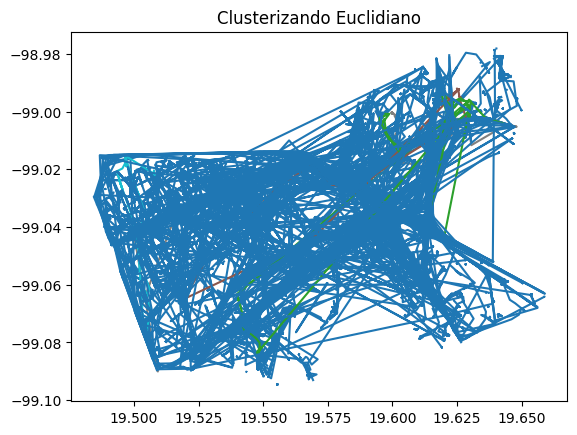

In [75]:
plot_clusters(trajectories, labels, "Clusterizando Euclidiano")

### Spatial Assembling Distance

In [76]:
labels_ed2 = model.fit_predict(compute_distance_matrix(trajectories, stmeasures.spatialassem_distance))

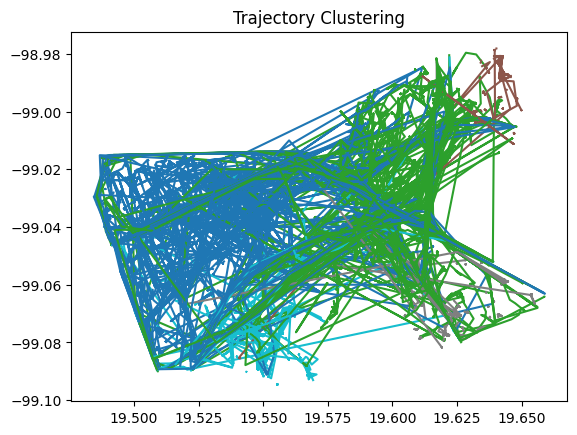

In [77]:
plot_clusters(trajectories, labels_ed2)

### Hausdorff

In [48]:
def hausdorff_distance(a, b):
    return shapely.hausdorff_distance(*utils.to_shapely(a, b))

In [79]:
labels_ha = model.fit_predict(compute_distance_matrix(trajectories, hausdorff_distance))

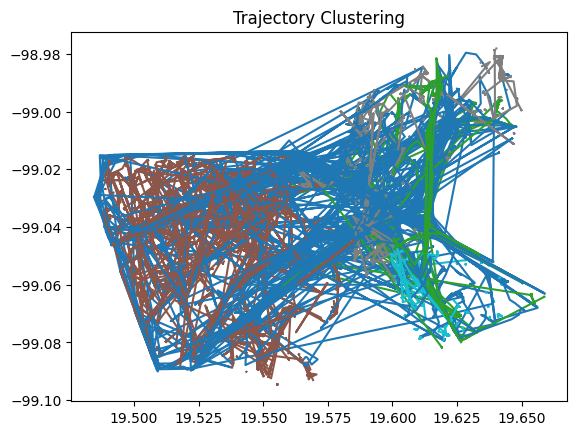

In [80]:
plot_clusters(trajectories, labels_ha)

### Frechet

In [81]:
def frechet_distance(a, b):
    return shapely.frechet_distance(*utils.to_shapely(a, b))

In [82]:
labels_fr = model.fit_predict(compute_distance_matrix(trajectories, frechet_distance))

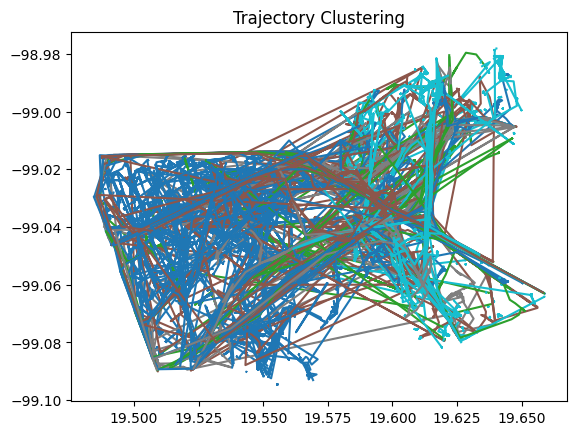

In [83]:
plot_clusters(trajectories, labels_fr)

In [90]:
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [91]:
labels_ed2

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 4, 4, 4, 4, 4, 1, 1, 1, 1, 3, 1,
       1, 1, 1, 1, 3, 3, 2, 2, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 0, 0, 0, 0,
       0, 0, 3, 3, 3, 3, 3, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 4, 4, 4, 4, 0,
       0, 4, 1, 1, 1, 1, 1, 1, 1, 1, 4, 0, 0, 0, 0, 1, 4, 4, 4, 4, 4, 4,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 2, 1, 1, 4,
       0, 4, 0, 0, 0, 0, 0, 0, 1, 0, 4, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       4, 4, 4, 3, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 4, 1, 1, 1, 0, 0, 0, 0, 4, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1,
       1, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 0, 3, 4, 4, 4, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 4, 1, 0, 4, 4, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 4, 4, 4, 4, 1, 3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       4, 1, 0, 1, 1, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4,

In [92]:
labels_fr

array([4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, 1, 3, 4, 0,
       2, 0, 0, 0, 4, 4, 4, 4, 4, 1, 2, 4, 4, 2, 4, 2, 4, 0, 0, 3, 0, 0,
       0, 3, 0, 3, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 0, 0, 0, 0,
       0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 4, 3, 4, 4, 4, 4, 3, 4, 3, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0,
       4, 3, 1, 0, 1, 0, 3, 1, 1, 1, 0, 0, 0, 0, 0, 2, 0, 0, 4, 4, 4, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0, 4, 4, 4, 4, 4, 0, 0, 2, 0,
       0, 0, 0, 4, 0, 3, 3, 4, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 0,
       1, 2, 4, 3, 4, 0, 2, 3, 2, 0, 3, 3, 4, 1, 4, 3, 3, 0, 0, 2, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 4, 2,
       2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 4, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 2, 1, 4, 4,
       4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 4, 0, 0, 0, 3, 0, 0, 0, 1,
       2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [93]:
labels_ha

array([3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 3, 0, 0, 4, 2,
       1, 3, 3, 3, 4, 4, 3, 3, 3, 0, 0, 3, 3, 0, 3, 1, 3, 0, 2, 0, 2, 2,
       2, 0, 2, 0, 3, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4, 4, 2, 2, 2, 2,
       2, 2, 4, 4, 4, 4, 4, 3, 3, 3, 0, 3, 3, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       2, 2, 1, 0, 1, 1, 3, 1, 0, 3, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0, 2, 2, 0, 0, 0, 3, 3, 3, 2,
       2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 0, 3, 3, 3, 3, 0, 2, 0, 0,
       2, 2, 2, 4, 0, 0, 0, 3, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 4, 0,
       0, 4, 4, 4, 4, 4, 4, 4, 3, 3, 4, 0, 4, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 0, 0, 3, 3,
       3, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 4, 2, 1, 2, 2, 2, 0, 2, 2, 2, 0,
       0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,

# Limpieza de datos
Lamentablemente los GeoJSON que se dieron no tienen trayectorias validas y en algunos casos solo contiene un punto en vez de un conjunto de puntos, por lo que se desarrolló la siguiente función para elminiar estos puntos y que se añade a `utils.py`

In [68]:
def get_only_trajectories(geojson, n):
    i = 0
    dataset = []
    len_geojson = len(geojson)
    
    while len(dataset) < n:
        if i >= len_geojson or n >= len_geojson:
            raise ValueError("Number of trajectories greater than dataset length")
        
        if len(geojson[i]) > 1:
            dataset.append(geojson[i])
        
        i += 1

    return dataset